#### Forecasting & Streamlit Preparation

**Goals**:
- Add simple time-series forecasting (monthly revenue & price) using Prophet
- Create lightweight aggregated datasets for fast dashboard loading
- Produce Plotly charts (interactive versions of key visuals)
- Export files needed by Streamlit app
- Test & validate outputs


#### Imports



In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from prophet import Prophet
import os

# For saving files
os.makedirs('../data/dashboard_ready', exist_ok=True)

#### Load Processed Data



In [2]:
df = pd.read_csv('../data/processed_rebar_sales.csv')
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

print("Loaded data shape:", df.shape)
print("Date range:", df['Order_Date'].min().date(), "to", df['Order_Date'].max().date())

Loaded data shape: (6938, 20)
Date range: 2020-01-31 to 2026-06-30


#### Create Monthly Aggregated Data

In [3]:
monthly = df.groupby(pd.Grouper(key='Order_Date', freq='ME')).agg({
    'Revenue_ETB': 'sum',
    'Quantity_kg': 'sum',
    'Unit_Price_ETB_kg': 'mean',
    'Est_Margin_ETB': 'sum',
    'Est_Margin_Pct': 'mean'
}).reset_index()

monthly['Revenue_M_ETB'] = (monthly['Revenue_ETB'] / 1_000_000).round(2)
monthly['Avg_Price_ETB_kg'] = monthly['Unit_Price_ETB_kg'].round(2)
monthly['Total_Margin_ETB'] = (monthly['Est_Margin_ETB'] / 1_000_000).round(2)

# Save for dashboard
monthly.to_csv('../data/dashboard_ready/monthly_agg.csv', index=False)
print("Monthly aggregation saved:", monthly.shape)
display(monthly.tail(8))

Monthly aggregation saved: (78, 9)


,Order_Date,Revenue_ETB,Quantity_kg,Unit_Price_ETB_kg,Est_Margin_ETB,Est_Margin_Pct,Revenue_M_ETB,Avg_Price_ETB_kg,Total_Margin_ETB
70,2025-11-30,330431984,895900,361.307640,83490829.0,26.174157,330.43,361.31,83.49
71,2025-12-31,200764443,553800,364.327037,50047830.0,25.993827,200.76,364.33,50.05
72,2026-01-31,219772675,546400,401.945169,61647711.0,26.629213,219.77,401.95,61.65
73,2026-02-28,256984063,659000,398.156300,72094116.0,27.558000,256.98,398.16,72.09
74,2026-03-31,228761361,566000,403.673896,61306038.0,27.007792,228.76,403.67,61.31
75,2026-04-30,296920565,728900,399.513960,78073767.0,27.433663,296.92,399.51,78.07
76,2026-05-31,244804401,601000,399.509333,63646089.0,27.266667,244.80,399.51,63.65
77,2026-06-30,216131132,688200,313.442130,56193822.0,27.011111,216.13,313.44,56.19


#### Simple Revenue Forecasting with Prophet



In [4]:
rev_prophet = monthly[['Order_Date', 'Revenue_ETB']].rename(columns={
    'Order_Date': 'ds',
    'Revenue_ETB': 'y'
})

m_rev = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative'
)
m_rev.fit(rev_prophet)

future_rev = m_rev.make_future_dataframe(periods=12, freq='ME')
forecast_rev = m_rev.predict(future_rev)

# Keep relevant columns
forecast_rev = forecast_rev[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_rev['yhat_M'] = (forecast_rev['yhat'] / 1_000_000).round(2)

print("Revenue forecast sample (last 5 historical + 5 future):")
display(forecast_rev.tail(10))

# Save
forecast_rev.to_csv('../data/dashboard_ready/forecast_revenue.csv', index=False)

16:00:26 - cmdstanpy - INFO - Chain [1] start processing
16:00:31 - cmdstanpy - INFO - Chain [1] done processing


Revenue forecast sample (last 5 historical + 5 future):


,ds,yhat,yhat_lower,yhat_upper,yhat_M
80,2026-09-30,1.936960e+08,1.560207e+08,2.298586e+08,193.70
81,2026-10-31,1.907806e+08,1.545081e+08,2.290853e+08,190.78
82,2026-11-30,3.146377e+08,2.777789e+08,3.497480e+08,314.64
83,2026-12-31,2.248627e+08,1.891194e+08,2.605925e+08,224.86
84,2027-01-31,2.692189e+08,2.334606e+08,3.063423e+08,269.22
85,2027-02-28,2.414680e+08,2.052459e+08,2.773055e+08,241.47
86,2027-03-31,2.932352e+08,2.551603e+08,3.295406e+08,293.24
87,2027-04-30,2.783087e+08,2.396859e+08,3.142666e+08,278.31
88,2027-05-31,3.290619e+08,2.894698e+08,3.676898e+08,329.06
89,2027-06-30,2.552053e+08,2.187168e+08,2.907805e+08,255.21


#### Simple Price Forecasting



In [5]:
price_prophet = monthly[['Order_Date', 'Unit_Price_ETB_kg']].rename(columns={
    'Order_Date': 'ds',
    'Unit_Price_ETB_kg': 'y'
})

m_price = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='additive'
)
m_price.fit(price_prophet)

future_price = m_price.make_future_dataframe(periods=12, freq='ME')
forecast_price = m_price.predict(future_price)

forecast_price = forecast_price[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]
forecast_price['yhat'] = forecast_price['yhat'].round(2)

print("Price forecast sample:")
display(forecast_price.tail(10))

forecast_price.to_csv('../data/dashboard_ready/forecast_price.csv', index=False)

16:01:12 - cmdstanpy - INFO - Chain [1] start processing
16:01:13 - cmdstanpy - INFO - Chain [1] done processing


Price forecast sample:


,ds,yhat,yhat_lower,yhat_upper
80,2026-09-30,331.79,321.703377,342.261604
81,2026-10-31,331.41,321.494003,341.259300
82,2026-11-30,390.35,379.530433,400.237163
83,2026-12-31,391.98,382.132905,401.722439
84,2027-01-31,426.94,416.094798,437.914989
85,2027-02-28,430.16,419.601317,440.788155
86,2027-03-31,428.66,418.506793,439.321978
87,2027-04-30,431.52,420.976079,442.308773
88,2027-05-31,430.32,420.348235,441.042499
89,2027-06-30,362.88,352.565433,373.237914


#### Plotly Interactive Charts



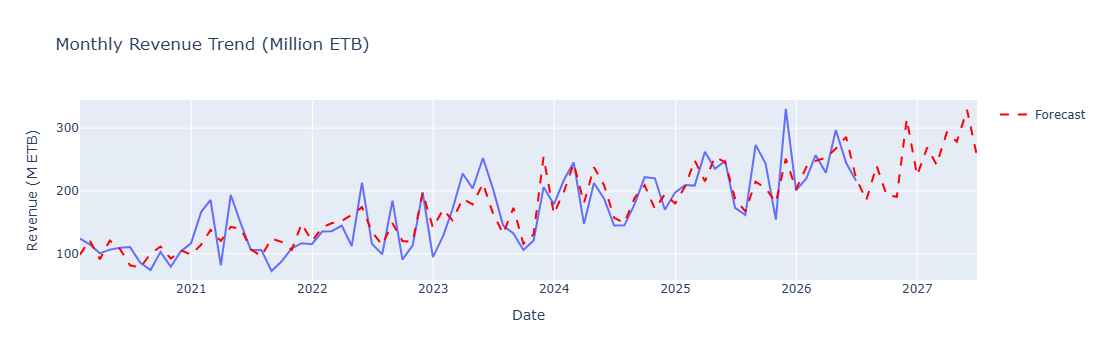

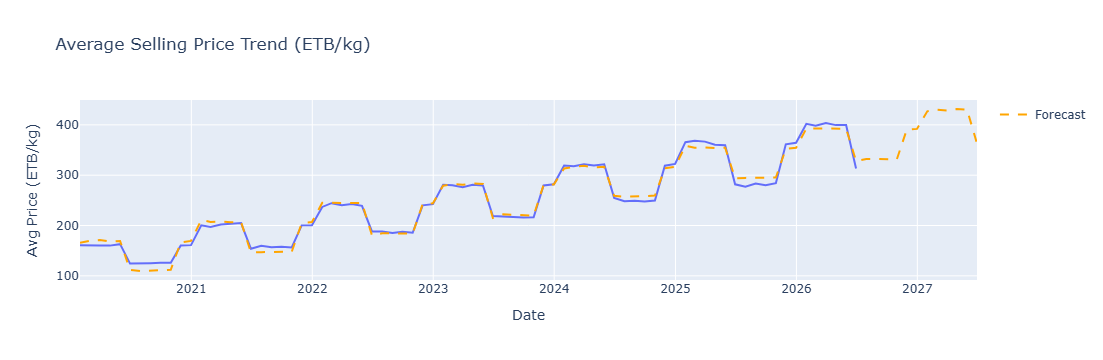

In [6]:
# 1. Revenue Trend + Forecast
fig_rev = px.line(
    monthly,
    x='Order_Date',
    y='Revenue_M_ETB',
    title='Monthly Revenue Trend (Million ETB)',
    labels={'Order_Date': 'Date', 'Revenue_M_ETB': 'Revenue (M ETB)'}
)

# Add forecast
fig_rev.add_scatter(
    x=forecast_rev['ds'],
    y=forecast_rev['yhat_M'],
    mode='lines',
    name='Forecast',
    line=dict(color='red', dash='dash')
)

fig_rev.update_layout(showlegend=True, hovermode='x unified')
fig_rev.show()

# 2. Price Trend + Forecast
fig_price = px.line(
    monthly,
    x='Order_Date',
    y='Avg_Price_ETB_kg',
    title='Average Selling Price Trend (ETB/kg)',
    labels={'Order_Date': 'Date', 'Avg_Price_ETB_kg': 'Avg Price (ETB/kg)'}
)

fig_price.add_scatter(
    x=forecast_price['ds'],
    y=forecast_price['yhat'],
    mode='lines',
    name='Forecast',
    line=dict(color='orange', dash='dash')
)

fig_price.update_layout(showlegend=True, hovermode='x unified')
fig_price.show()

# Optional: Save as HTML for testing (open in browser)
fig_rev.write_html('../data/dashboard_ready/revenue_trend.html')
fig_price.write_html('../data/dashboard_ready/price_trend.html')

#### Top Categories Summary



In [7]:
# Quick top summaries
top_products = df.groupby('Product')['Revenue_ETB'].sum().nlargest(6).round(0) / 1e9
top_regions  = df.groupby('Region')['Revenue_ETB'].sum().nlargest(5).round(0) / 1e9

print("Top 6 Products by Revenue (Billion ETB):")
print(top_products.to_string())

print("\nTop Regions by Revenue (Billion ETB):")
print(top_regions.to_string())

# Optional: save small CSV for dashboard sidebar
pd.DataFrame({
    'Category': top_products.index,
    'Revenue_B_ETB': top_products.values
}).to_csv('../data/dashboard_ready/top_products.csv', index=False)

pd.DataFrame({
    'Region': top_regions.index,
    'Revenue_B_ETB': top_regions.values
}).to_csv('../data/dashboard_ready/top_regions.csv', index=False)

Top 6 Products by Revenue (Billion ETB):
Product
Rebar 16mm Imported (Turkey)    2.046091
Rebar 6mm G60                   1.881414
Rebar 8mm G75                   1.565275
Rebar 12mm G75                  1.560401
Rebar 10mm G75                  1.537326
Rebar 14mm G75                  1.486501

Top Regions by Revenue (Billion ETB):
Region
Addis Ababa       5.265787
Oromia            3.937721
Amhara            1.975960
Sidama            0.956949
South Ethiopia    0.744444
